In [17]:
import numpy as np
import pandas as pd


In [18]:
df = pd.read_csv("../data/uav_fault_dataset_v2.csv")

In [19]:
df.shape

(180812, 25)

In [20]:
df.head(3)

,bag,timestamp_ns,roll_cmd,roll_meas,roll_error,pitch_cmd,pitch_meas,pitch_error,yaw_cmd,yaw_meas,yaw_error,vel_x,vel_y,vel_z,imu_x,imu_y,imu_z,engine_fault,aileron_fault,elevator_fault,rudder_fault,ground_speed,binary_fault,time_sec,yaw_error_clean
0,carbonZ_2018-07-18-12-10-11.bag,1531930511391720552,0.10,2.954323,-2.854323,-2.55,8.487809,-11.037809,0.0,-86.14962,86.14962,-19.941626,-0.312905,4.295179,-0.0748,-0.023208,-0.996428,0,0,0,0,20.401346,0,0.000000,86.14962
1,carbonZ_2018-07-18-12-10-11.bag,1531930511452938696,30.34,2.954323,27.385678,-1.31,8.487809,-9.797809,88.0,-86.14962,174.14962,-19.941626,-0.312905,4.295179,-0.0748,-0.023208,-0.996428,0,0,0,0,20.401346,0,0.061218,174.14962
2,carbonZ_2018-07-18-12-10-11.bag,1531930511484229416,30.32,2.954323,27.365677,-1.31,8.487809,-9.797809,88.0,-86.14962,174.14962,-19.941626,-0.312905,4.295179,-0.0748,-0.023208,-0.996428,0,0,0,0,20.401346,0,0.092509,174.14962


# Missing values

In [21]:
df.isnull().sum()

bag                0
timestamp_ns       0
roll_cmd           0
roll_meas          0
roll_error         0
pitch_cmd          0
pitch_meas         0
pitch_error        0
yaw_cmd            0
yaw_meas           0
yaw_error          0
vel_x              0
vel_y              0
vel_z              0
imu_x              0
imu_y              0
imu_z              0
engine_fault       0
aileron_fault      0
elevator_fault     0
rudder_fault       0
ground_speed       0
binary_fault       0
time_sec           0
yaw_error_clean    0
dtype: int64

In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
timestamp_ns,180812.0,1.536186e+18,2.552247e+15,1.531931e+18,1.532987e+18,1.536692e+18,1.538765e+18,1.539876e+18
roll_cmd,180812.0,1.085774e-01,2.213079e+01,-4.500000e+01,-2.150250e+01,-9.999999e-02,9.700000e+00,4.499000e+01
roll_meas,180812.0,5.609018e+00,1.767877e+01,-6.645238e+01,-1.070823e+00,1.802363e+00,9.861669e+00,7.128139e+01
roll_error,180812.0,-5.500441e+00,1.441541e+01,-1.062053e+02,-1.728321e+01,-2.406277e+00,2.745284e+00,9.828865e+01
pitch_cmd,180812.0,-6.179695e-01,5.301747e+00,-2.499000e+01,-2.620000e+00,0.000000e+00,1.030000e+00,2.000000e+01
pitch_meas,180812.0,5.292030e-01,6.004527e+00,-5.688078e+01,-1.096565e+00,5.454269e-01,2.054308e+00,7.293653e+01
pitch_error,180812.0,-1.147173e+00,6.450553e+00,-9.304937e+01,-3.104228e+00,-5.996998e-01,1.073058e+00,5.941078e+01
yaw_cmd,180812.0,1.095005e+01,1.038293e+02,-1.790000e+02,-8.200000e+01,0.000000e+00,1.130000e+02,1.800000e+02
yaw_meas,180812.0,-4.744680e+01,9.914901e+01,-1.799952e+02,-1.238708e+02,-8.398824e+01,2.515860e+01,1.799866e+02
yaw_error,180812.0,5.839685e+01,1.326115e+02,-3.587891e+02,-5.047535e+00,1.907950e+01,1.137684e+02,3.589952e+02


In [23]:
# Calculate differences between consecutive rows in nanoseconds
time_gaps = df['timestamp_ns'].diff()
print(time_gaps.describe())


count    1.808110e+05
mean     4.394364e+10
std      1.048241e+13
min      3.520000e+02
25%      2.784288e+07
50%      4.407363e+07
75%      6.173583e+07
max      3.694017e+15
Name: timestamp_ns, dtype: float64


In [24]:
# Force an absolute chronological sort across the entire dataset
df = df.sort_values(by='timestamp_ns').reset_index(drop=True)


In [25]:
df.head(3)

,bag,timestamp_ns,roll_cmd,roll_meas,roll_error,pitch_cmd,pitch_meas,pitch_error,yaw_cmd,yaw_meas,yaw_error,vel_x,vel_y,vel_z,imu_x,imu_y,imu_z,engine_fault,aileron_fault,elevator_fault,rudder_fault,ground_speed,binary_fault,time_sec,yaw_error_clean
0,carbonZ_2018-07-18-12-10-11.bag,1531930511391720552,0.10,2.954323,-2.854323,-2.55,8.487809,-11.037809,0.0,-86.14962,86.14962,-19.941626,-0.312905,4.295179,-0.0748,-0.023208,-0.996428,0,0,0,0,20.401346,0,0.000000,86.14962
1,carbonZ_2018-07-18-12-10-11.bag,1531930511452938696,30.34,2.954323,27.385678,-1.31,8.487809,-9.797809,88.0,-86.14962,174.14962,-19.941626,-0.312905,4.295179,-0.0748,-0.023208,-0.996428,0,0,0,0,20.401346,0,0.061218,174.14962
2,carbonZ_2018-07-18-12-10-11.bag,1531930511484229416,30.32,2.954323,27.365677,-1.31,8.487809,-9.797809,88.0,-86.14962,174.14962,-19.941626,-0.312905,4.295179,-0.0748,-0.023208,-0.996428,0,0,0,0,20.401346,0,0.092509,174.14962


In [26]:
# Calculate the exact difference between consecutive rows in nanoseconds
time_gaps = df['timestamp_ns'].diff()

# 5 seconds expressed in nanoseconds is 5 * 10^9
five_seconds_in_ns = 5_000_000_000

# Mark a new flight ID every time a gap exceeds 5 seconds
df['flight_id'] = (time_gaps > five_seconds_in_ns).cumsum()

print(f"Isolated {df['flight_id'].nunique()} independent flight blocks.")

Isolated 85 independent flight blocks.


In [29]:
processed_flights = []

# Loop through each flight log independently
for flight_id, group in df.groupby('flight_id'):
    group = group.copy()
    
    # 1. Convert the nanosecond integer into a real Pandas datetime index
    group['datetime'] = pd.to_datetime(group['timestamp_ns'], unit='ns')
    group.set_index('datetime', inplace=True)
    
    # 2. SEPARATION: Split numeric sensors from target/meta fields
    # This prevents the .mean() calculation from crashing on text or ID columns
    numeric_cols = group.select_dtypes(include=['number']).columns
    
    # 3. Resample only the numeric telemetry data using the mean
    flight_resampled = group[numeric_cols].resample('50ms').mean()
    
    # 4. Clean up structural time steps with forward-fill and back-fill
    flight_resampled = flight_resampled.ffill().bfill()
    
    # 5. Restore the flight ID tracking field explicitly as a numeric type
    flight_resampled['flight_id'] = int(flight_id)
    
    processed_flights.append(flight_resampled)

# Re-combine into your final time-series structured dataset
df_time_series_ready = pd.concat(processed_flights)
print("Time-series grid alignment successful!")
print("New dataframe shape:", df_time_series_ready.shape)


Time-series grid alignment successful!
New dataframe shape: (166136, 25)


In [30]:
# List of the multi-class fault columns to discard
faults_to_drop = ['engine_fault', 'aileron_fault', 'elevator_fault', 'rudder_fault','time_sec','yaw_error']

# Drop columns safely if they exist in the dataframe
df_time_series_ready = df_time_series_ready.drop(columns=faults_to_drop, errors='ignore')

print("Columns successfully dropped!")
print("Remaining columns in your dataset:")
print(list(df_time_series_ready.columns))


Columns successfully dropped!
Remaining columns in your dataset:
['timestamp_ns', 'roll_cmd', 'roll_meas', 'roll_error', 'pitch_cmd', 'pitch_meas', 'pitch_error', 'yaw_cmd', 'yaw_meas', 'vel_x', 'vel_y', 'vel_z', 'imu_x', 'imu_y', 'imu_z', 'ground_speed', 'binary_fault', 'yaw_error_clean', 'flight_id']


In [34]:
df_time_series_ready.tail(3)

,timestamp_ns,roll_cmd,roll_meas,roll_error,pitch_cmd,pitch_meas,pitch_error,yaw_cmd,yaw_meas,vel_x,vel_y,vel_z,imu_x,imu_y,imu_z,ground_speed,binary_fault,yaw_error_clean,flight_id
datetime,,,,,,,,,,,,,,,,,,,
2018-10-18 15:20:04.850,1.539876e+18,-0.15,5.045389,-5.195389,18.58,3.030872,15.549128,-82.0,-78.366837,-8.930411,1.062071,-2.207152,-0.030744,-0.041096,-0.993658,9.260225,1.0,-3.633163,84
2018-10-18 15:20:04.900,1.539876e+18,-0.33,5.045389,-5.375389,18.58,3.030872,15.549128,-82.0,-78.366837,-8.930411,1.062071,-2.207152,-0.030744,-0.041096,-0.993658,9.260225,1.0,-3.633163,84
2018-10-18 15:20:04.950,1.539876e+18,-0.33,5.045389,-5.375389,18.58,3.030872,15.549128,-82.0,-78.366837,-8.870027,1.092030,-2.260587,-0.030744,-0.041096,-0.993658,9.218468,1.0,-3.633163,84


In [33]:
df_time_series_ready.describe().T

,count,mean,std,min,25%,50%,75%,max
timestamp_ns,166136.0,1.535908e+18,2.588206e+15,1.531931e+18,1.532985e+18,1.536692e+18,1.536704e+18,1.539876e+18
roll_cmd,166136.0,4.123003e-01,2.143177e+01,-4.500000e+01,-1.801000e+01,-9.999999e-02,9.719999e+00,4.499000e+01
roll_meas,166136.0,5.501855e+00,1.750355e+01,-6.645238e+01,-1.073205e+00,1.805565e+00,1.065474e+01,7.128139e+01
roll_error,166136.0,-5.089555e+00,1.393236e+01,-1.062053e+02,-1.623827e+01,-2.440682e+00,2.648560e+00,9.828865e+01
pitch_cmd,166136.0,-5.429272e-01,5.221569e+00,-2.499000e+01,-2.620000e+00,0.000000e+00,1.210000e+00,2.000000e+01
pitch_meas,166136.0,6.214369e-01,6.095086e+00,-5.688078e+01,-1.132055e+00,5.337540e-01,2.083298e+00,7.293653e+01
pitch_error,166136.0,-1.164364e+00,6.514063e+00,-9.304937e+01,-3.222494e+00,-6.049160e-01,1.164905e+00,5.941078e+01
yaw_cmd,166136.0,6.808006e+00,1.024432e+02,-1.790000e+02,-8.200000e+01,0.000000e+00,1.003333e+02,1.800000e+02
yaw_meas,166136.0,-4.470074e+01,9.785750e+01,-1.799952e+02,-1.159781e+02,-8.126379e+01,2.535170e+01,1.799866e+02
vel_x,166136.0,-1.728765e-01,1.183739e+01,-2.541893e+01,-1.065884e+01,9.526105e-02,9.501533e+00,3.148082e+01


In [37]:
df_time_series_ready.dtypes

timestamp_ns       float64
roll_cmd           float64
roll_meas          float64
roll_error         float64
pitch_cmd          float64
pitch_meas         float64
pitch_error        float64
yaw_cmd            float64
yaw_meas           float64
vel_x              float64
vel_y              float64
vel_z              float64
imu_x              float64
imu_y              float64
imu_z              float64
ground_speed       float64
binary_fault       float64
yaw_error_clean    float64
flight_id            int64
dtype: object

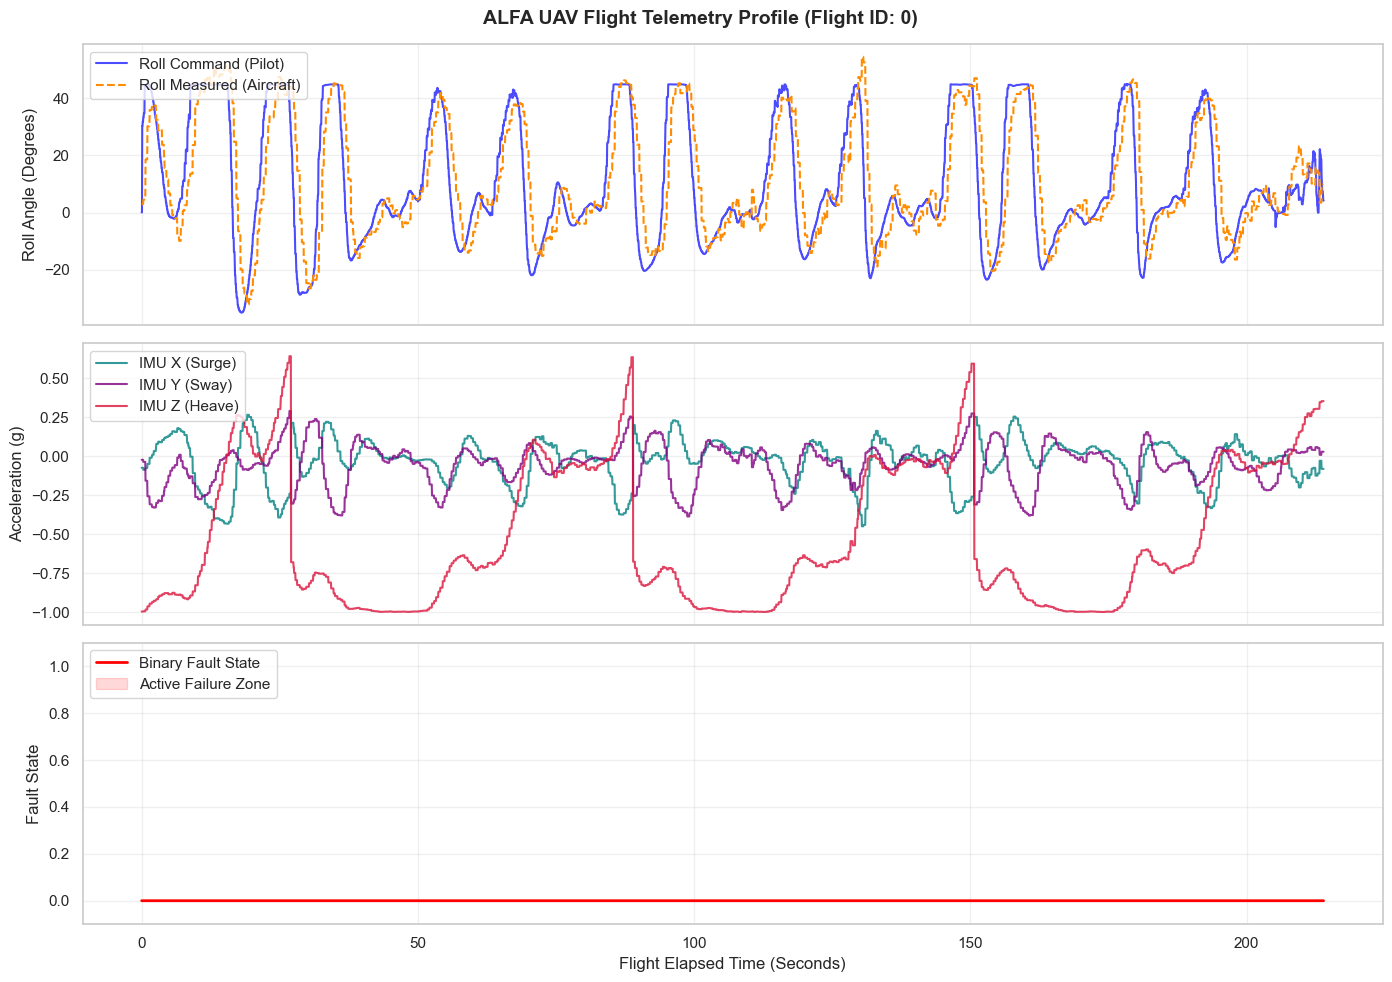

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Isolate the very first flight profile to visualize its timeline
flight_sample = df_time_series_ready[df_time_series_ready['flight_id'] == 0].copy()

# Create a clean relative time tracker in seconds starting from 0 for this flight
flight_sample['elapsed_sec'] = (flight_sample.index - flight_sample.index[0]).total_seconds()

# 2. Initialize a 3-panel stacked time series plot
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('ALFA UAV Flight Telemetry Profile (Flight ID: 0)', fontsize=14, fontweight='bold')

# Panel 1: Roll Control Tracking (Command vs. Actual Response)
ax1.plot(flight_sample['elapsed_sec'], flight_sample['roll_cmd'], label='Roll Command (Pilot)', color='blue', alpha=0.7)
ax1.plot(flight_sample['elapsed_sec'], flight_sample['roll_meas'], label='Roll Measured (Aircraft)', color='darkorange', linestyle='--')
ax1.set_ylabel('Roll Angle (Degrees)')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# Panel 2: Physical Airframe Forces (IMU Accelerometer Data)
ax2.plot(flight_sample['elapsed_sec'], flight_sample['imu_x'], label='IMU X (Surge)', color='teal', alpha=0.8)
ax2.plot(flight_sample['elapsed_sec'], flight_sample['imu_y'], label='IMU Y (Sway)', color='purple', alpha=0.8)
ax2.plot(flight_sample['elapsed_sec'], flight_sample['imu_z'], label='IMU Z (Heave)', color='crimson', alpha=0.8)
ax2.set_ylabel('Acceleration (g)')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')

# Panel 3: Anomaly Target Vector (Ground Truth)
# Shading the background region where the failure condition is active
ax3.plot(flight_sample['elapsed_sec'], flight_sample['binary_fault'], label='Binary Fault State', color='red', linewidth=2)
ax3.fill_between(flight_sample['elapsed_sec'], 0, flight_sample['binary_fault'], color='red', alpha=0.15, label='Active Failure Zone')
ax3.set_ylabel('Fault State')
ax3.set_xlabel('Flight Elapsed Time (Seconds)')
ax3.set_ylim(-0.1, 1.1)
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [41]:
# Group by flight_id and check the maximum fault value in each flight
flight_summary = df_time_series_ready.groupby('flight_id')['binary_fault'].max()

# Print flights that have an active failure zone (where max fault == 1)
anomaly_flights = flight_summary[flight_summary == 1].index.tolist()
print("Flights containing an active failure zone:", anomaly_flights)

# Print flights that are completely normal (where max fault == 0)
healthy_flights = flight_summary[flight_summary == 0].index.tolist()
print("Completely healthy flights:", healthy_flights)


Flights containing an active failure zone: [3, 5, 6, 7, 8, 9, 12, 14, 15, 16, 17, 18, 21, 22, 24, 28, 32, 35, 37, 38, 41, 46, 47, 48, 54, 56, 57, 59, 65, 66, 68, 69, 73, 75, 77, 78, 79, 80, 81, 82, 84]
Completely healthy flights: [0, 1, 2, 4, 10, 11, 13, 19, 20, 23, 25, 26, 27, 29, 30, 31, 33, 34, 36, 39, 40, 42, 43, 44, 45, 49, 50, 51, 52, 53, 55, 58, 60, 61, 62, 63, 64, 67, 70, 71, 72, 74, 76, 83]
